# Week 11 - scanpy demo

**Step 0: Rename files to work with scanpy**

You may be able to do this outside of python

In [11]:
import gzip, glob, shutil, os

DATA_DIR = "./data/GSE278688"

# find all the .gz files
files = glob.glob(f'{DATA_DIR}/GSE278688*.gz')
for gzfile in files:
    print(f'renaming file {gzfile} to {outfile}')
    outfile = gzfile.replace('GSE278688_sc_','')
    os.rename(gzfile, outfile)


**Step 1: Import libraries**

Scanpy (sc) will serve as our core single-cell analysis framework 
AnnData is a data structure Python package that will store our data matrices for scRNA seq analysis.

In [12]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

sc.settings.verbosity = 2
sc.settings.seed = 42
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(6, 5))

ad.settings.allow_write_nullable_strings = True


/var/folders/1v/z7159g391sd3b__mmrk2g4kh0000gn/T/ipykernel_38490/3605026609.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(6, 5))


**Step 2: Load Data**

GSE278688 is a PDAC (pancreatic ductal adenocarcinoma) scRNA-seq dataset 
from Chen et al. Cancer Cell 2025 (https://www.cell.com/cancer-cell/fulltext/S1535-6108(25)00270-3). The three files *matrix, barcodes, features* are the standard 10x Genomics CellRanger output format.

**Why subsample to 5,000 cells?**
The full dataset is ~100k+ cells so we subsampled 5,000 to speed up the run time and ensure our computers have enough feasible RAM to complete the analysis. 5,000 cells captured the major immune populations while running in 2-3 minutes instead of hours. 

In [14]:
DATA_DIR = "./data/GSE278688"

adata = sc.read_10x_mtx(
    DATA_DIR,
    var_names="gene_symbols",
    cache=True
)
adata.var_names_make_unique()
print(adata)


... reading from cache file cache/data-GSE278688-matrix.h5ad
AnnData object with n_obs × n_vars = 199184 × 30543
    var: 'gene_ids', 'feature_types'


In [15]:
# Subsample to 5,000 cells for demo
sc.pp.subsample(adata, n_obs=5000, random_state=42)
print(adata)

AnnData object with n_obs × n_vars = 5000 × 30543
    var: 'gene_ids', 'feature_types'


**Step 3: Quality Control & Filtering**
Raw scRNA-seq data contains three types of low-quality observations we must remove:

1. **Empty droplets** — captured no cell, just ambient RNA, i.e., very few genes detected
2. **Dead/damaged cells** — lost cytoplasmic mRNA, only mitochondrial transcripts remain, leading to a high MT%
3. **Doublets** — two cells in one droplet, leading to abnormally high gene counts

**Thresholds used:**
- `min_genes=200`: removes empty droplets
- `max_genes=6000`: removes likely doublets  
- `pct_counts_mt < 20%`: removes dead/damaged cells
- `min_cells=3`: removes genes too sparse to be informative

**Why this matters for immune profiling:** Retaining dead cells inflates 
myeloid-like signatures (mitochondria-rich), and doublets create false 
hybrid T+B cell phenotypes that confuse downstream annotation. Also, double-positive immune populations carry phenotypic and functional differences that can lead to biological misinterpretations, e.g., a CD8+CD20+ T cell is very different than a CD3+CD8+ T cell. 

In [17]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=6000)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20, :].copy()

print(f"Cells after filtering: {adata.n_obs}")

filtered out 8877 genes that are detected in less than 3 cells
Cells after filtering: 4977


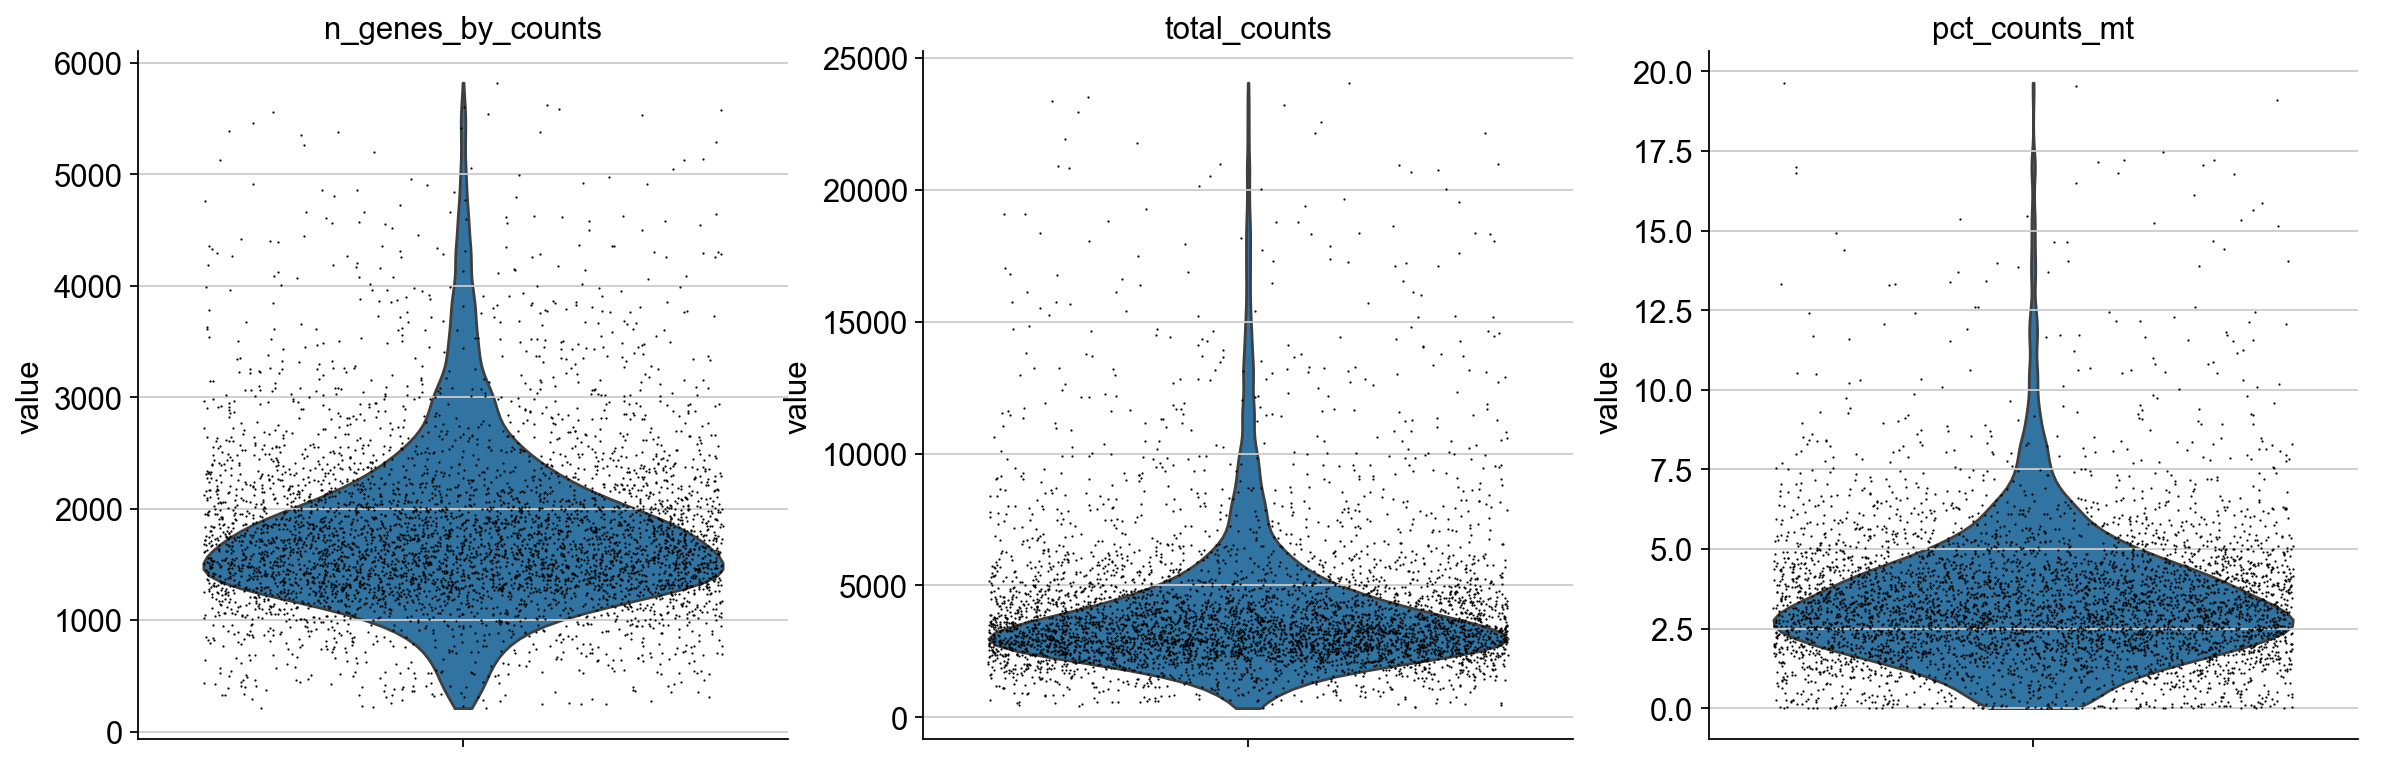

In [18]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, 
                           log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

**Step 4: Normalization & Log-Transformation**
Different cells have different sequencing depths. A cell captured in a deep well generates more total Unique molecular identifiers (UMIs) even with identical gene expression. Without correction, cells would cluster by sequencing depth, not biology.

In [19]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4) #scales every cell to 10,000 total counts
sc.pp.log1p(adata) # compresses the range of highly expressed genes and better normalizes the distribution
print("Normalization complete.")

normalizing counts per cell
    finished (0:00:00)
Normalization complete.


In [20]:
# needed to install to the local jupyter enviornment, since I had multiple Python enviornments

import sys
!{sys.executable} -m pip install scikit-misc

Step 5: Feature Selection, Scaling & PCA
Steps that prepare the data for embedding:

**Highly Variable Genes (HVGs):** Of ~21,000 genes, most are either lowly 
expressed noise or housekeeping genes identical across all cells. We select 
the top 2,000 genes with the highest cell-to-cell variability, i.e., these will help us distinguish 
disparate immune populations.

**Scaling:** PCA requires all genes to be on the same scale. We center each gene to zero mean and unit variance so no single highly-expressed gene dominates the principal components.

**PCA:** Compresses 2,000 gene dimensions into 30 principal components, capturing the major axes of variation. This removes some noise from the data, making the neighbor graph analysis in the next step reliable.

**Step 6: Neighborhood Graph, UMAP, & Clustering**
The final three steps of preprocessing:

**Neighbors (kNN graph):** Connects each cell to its 15 most similar neighbors in PCA space. This graph is the foundation for both UMAP and Leiden clustering.

**UMAP:** Projects the kNN graph into 2D for visualization. Cells with similar transcriptomes appear close together. Key note: distances between clusters are not strictly interpretable, whereas cluster membership matters.

**Leiden clustering:** Community detection on the kNN graph that identifies groups of densely connected cells. `resolution=0.5` gives broad immune lineages (T cell, B cell, myeloid, NK). Higher resolution (e.g., 1.0) would split these into finer subtypes e.g., B cell (naïve mature, activated, GC, plasma, memory, regulatory etc).

In [22]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", layer="counts")
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30, random_state=42)
print("PCA complete.")

extracting highly variable genes
computing PCA
    with n_comps=30


/Users/svd/opt/anaconda3/envs/scanp642/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:00)
PCA complete.


In [23]:
# needed to install to the local jupyter enviornment, since I had multiple Python enviornments

import sys
!{sys.executable} -m pip install leidenalg igraph

**Step 7: Visualize Clusters**
The UMAP colored by Leiden cluster ID. Each number (0–12) is a defined group of transcriptionally similar cells. 
These numbers have no biological meaning yet, that comes from CellTypist annotation in the downstream analysis.

However, preprocessing is complete: we have gone from raw counts to a cleaned, normalized, clustered dataset ready for cell annotation.

In [24]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20, random_state=42)
sc.tl.umap(adata, random_state=42)
sc.tl.leiden(adata, resolution=0.5, random_state=42, flavor="igraph", n_iterations=2, directed=False)
print(f"Clusters: {adata.obs['leiden'].nunique()}")

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished (0:00:00)
computing UMAP
    finished (0:00:11)
running Leiden clustering
    finished (0:00:01)
Clusters: 13


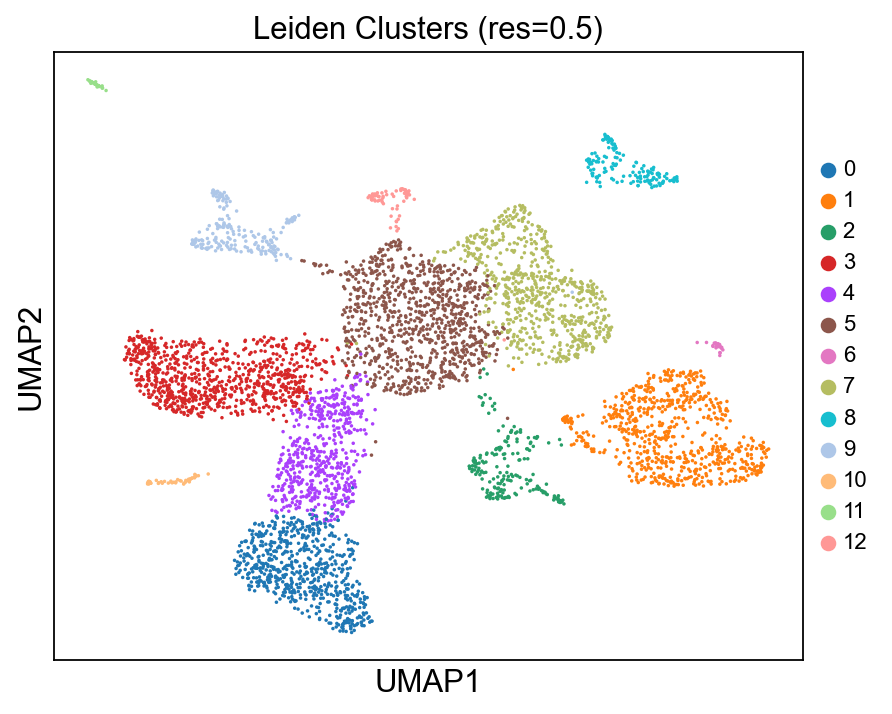

In [25]:
sc.pl.umap(
    adata, 
    color=["leiden"], 
    legend_loc="right margin",  # moves legend to the side
    legend_fontsize=10,
    size=10,
    title="Leiden Clusters (res=0.5)"
)